<a href="https://colab.research.google.com/github/LielUziahu/12th_GetTogether/blob/main/symbionts_count.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Block 1: Data Preparation & Splitting into 4 Treatments
This block loads the data, ensures numeric formatting, isolates the HF vs NF morphs, and splits the dataset based exactly on your defined conditions.

In [41]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Load the data
df = pd.read_csv('combine_spat_cell_count.csv')

# Clean and filter
df['Conc (Cell/polyp)'] = pd.to_numeric(df['Conc (Cell/polyp)'], errors='coerce')
df = df.dropna(subset=['Conc (Cell/polyp)'])
df = df[df['morph'].isin(['HF', 'NF'])].copy()

sub_condition_mapping_order = [
    'Ambient \n(23°C, pH 8.2, 10m)',
    '27°C',
    '32°C',
    'pH 7.8',
    'pH 7.6',
    '50m',
    'Dark',
]

def assign_full_conditions(row):
    if row['temp'] == 23 and row['pH'] == 8.2 and row['light'] == '10m':
        return 'Ambient', 'Ambient \n(23°C, pH 8.2, 10m)'
    elif row['temp'] == 27 and row['pH'] == 8.2 and row['light'] == '10m':
        return 'Temperature', '27°C'
    elif row['temp'] == 32 and row['pH'] == 8.2 and row['light'] == '10m':
        return 'Temperature', '32°C'
    elif row['pH'] == 7.8 and row['temp'] == 23 and row['light'] == '10m':
        return 'pH', 'pH 7.8'
    elif row['pH'] == 7.6 and row['temp'] == 23 and row['light'] == '10m':
        return 'pH', 'pH 7.6'
    elif row['light'] == '50m' and row['temp'] == 23 and row['pH'] == 8.2:
        return 'Light', '50m'
    elif row['light'] == 'Dark' and row['temp'] == 23 and row['pH'] == 8.2:
        return 'Light', 'Dark'
    return 'Exclude', 'Exclude'

df[['Condition', 'Sub_Condition']] = df.apply(lambda row: pd.Series(assign_full_conditions(row)), axis=1)
df = df[df['Condition'] != 'Exclude'].copy()

condition_order_broad = ['Ambient', 'Temperature', 'pH', 'Light']
df['Condition'] = pd.Categorical(df['Condition'], categories=condition_order_broad, ordered=True)
df['Sub_Condition'] = pd.Categorical(df['Sub_Condition'], categories=sub_condition_mapping_order, ordered=True)

area_factors_per_morph_treatment = {
    ('HF', 'Ambient \n(23°C, pH 8.2, 10m)'): 2.566,
    ('NF', 'Ambient \n(23°C, pH 8.2, 10m)'): 2.151,
    ('HF', '27°C'): 2.943,
    ('NF', '27°C'): 2.989,
    ('HF', '32°C'): 2.745,
    ('NF', '32°C'): 3.255,
    ('HF', 'pH 7.8'): 1.658,
    ('NF', 'pH 7.8'): 2.374,
    ('HF', 'pH 7.6'): 2.447,
    ('NF', 'pH 7.6'): 2.860,
    ('HF', '50m'): 3.079,
    ('NF', '50m'): 3.889,
    ('HF', 'Dark'): 3.795,
    ('NF', 'Dark'): 2.722,
}

def get_area_factor(row):
    key = (row['morph'], row['Sub_Condition'])
    return area_factors_per_morph_treatment.get(key, 1.0)

df['Area_Factor'] = df.apply(get_area_factor, axis=1)
# Correct unit conversion: cells/um2 is cells/mm2 divided by 1,000,000
df['Cell_per_area_um2'] = (df['Conc (Cell/polyp)'] / df['Area_Factor']) / 1_000_000

print("Data unified. Units converted to cells/µm².")

Data unified. Units converted to cells/µm².


# Block 2: Global Poster Styling
This block sets the exact font sizes and colors we discussed earlier, including the transparent background so your plots will seamlessly integrate into your poster.

In [42]:

import matplotlib.pyplot as plt
import seaborn as sns

# --- GLOBAL PLOT STYLING ---
plt.rcParams.update({
    "font.family": "Serif",
    "font.size": 14,          # Global text size
    "axes.titlesize": 16,     # Plot titles
    "axes.labelsize": 14,     # Axis labels
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2
})

# --- GLOBAL COLOR PALETTE & PLOT ARTIFACTS ---
variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}

plot_order = [
    'Ambient \n(23°C, pH 8.2, 10m)',
    '27°C',
    '32°C',
    'pH 7.8',
    'pH 7.6',
    '50m',
    'Dark',
]

global_fig_size = (10, 6)
global_jitter = 0.2
global_marker_size = 5
global_alpha = 0.6
# Centralized Asterisk Settings
global_asterisk_size = 18
global_asterisk_weight = 'bold'

# Added for cleaner look
global_y_nbins = 3

print("Global styling (with bold asterisks and reduced Y-ticks) initialized.")

Global styling (with bold asterisks and reduced Y-ticks) initialized.


In [44]:
# --- BLOCK 3: STANDALONE NORMALITY CHECK ---

print("="*65)
print("SHAPIRO-WILK NORMALITY TEST REPORT")
print("="*65)

# Updated to use the correct converted unit column name
metrics_list = ['Conc (Cell/polyp)', 'Cell_per_area_um2']
# Use sub_condition_mapping_order for detailed treatment analysis
conditions_list_granular = sub_condition_mapping_order

# Dictionary to store normality results for subsequent blocks
normality_results = {}

for metric in metrics_list:
    print(f"\nMetric: {metric}")
    print("-" * 40)
    normality_results[metric] = {}

    for sub_condition_label in conditions_list_granular:
        cond_df = df[df['Sub_Condition'] == sub_condition_label] # Filter by Sub_Condition
        normality_results[metric][sub_condition_label] = {} # Key by Sub_Condition

        # Skip if no data for this sub_condition
        if len(cond_df) == 0:
            print(f"[{sub_condition_label} - No Data] Insufficient data for normality test (< 3 samples)")
            normality_results[metric][sub_condition_label]['HF'] = False
            normality_results[metric][sub_condition_label]['NF'] = False
            continue

        for morph in ['HF', 'NF']:
            group_data = cond_df[cond_df['morph'] == morph][metric].dropna()
            n_samples = len(group_data)

            # Shapiro-Wilk requires at least 3 samples
            if n_samples >= 3:
                stat, p_val = stats.shapiro(group_data)
                is_normal = p_val > 0.05
                status = "✅ Normal (Parametric)" if is_normal else "❌ Non-Normal (Non-Parametric)"

                print(f"[{sub_condition_label} - {morph}] n = {n_samples} | W = {stat:.4f} | p-value = {p_val:.4f} -> {status}")
                normality_results[metric][sub_condition_label][morph] = is_normal
            else:
                print(f"[{sub_condition_label} - {morph}] n = {n_samples} | Insufficient data for normality test (< 3 samples)")
                normality_results[metric][sub_condition_label][morph] = False

print("\nNormality checking complete. Ready for Block 4 (Outlier Removal & Statistics Engine).")

SHAPIRO-WILK NORMALITY TEST REPORT

Metric: Conc (Cell/polyp)
----------------------------------------
[Ambient 
(23°C, pH 8.2, 10m) - HF] n = 17 | W = 0.9455 | p-value = 0.3889 -> ✅ Normal (Parametric)
[Ambient 
(23°C, pH 8.2, 10m) - NF] n = 11 | W = 0.9227 | p-value = 0.3414 -> ✅ Normal (Parametric)
[27°C - HF] n = 7 | W = 0.9686 | p-value = 0.8884 -> ✅ Normal (Parametric)
[27°C - NF] n = 8 | W = 0.9423 | p-value = 0.6337 -> ✅ Normal (Parametric)
[32°C - HF] n = 3 | W = 0.8322 | p-value = 0.1939 -> ✅ Normal (Parametric)
[32°C - NF] n = 4 | W = 0.8275 | p-value = 0.1613 -> ✅ Normal (Parametric)
[pH 7.8 - HF] n = 5 | W = 0.8800 | p-value = 0.3095 -> ✅ Normal (Parametric)
[pH 7.8 - NF] n = 3 | W = 0.9643 | p-value = 0.6369 -> ✅ Normal (Parametric)
[pH 7.6 - HF] n = 4 | W = 0.9015 | p-value = 0.4386 -> ✅ Normal (Parametric)
[pH 7.6 - NF] n = 2 | Insufficient data for normality test (< 3 samples)
 - HF] n = 7 | W = 0.8795 | p-value = 0.2244 -> ✅ Normal (Parametric)
 - NF] n = 5 | W = 0.92

# Block 3: The Combined Cleaning & Stats Engine
To be scientifically rigorous, we must calculate outliers and statistics within each specific condition and morphotype. This block processes the master dataframe, returns a perfectly clean dataset, and saves the p-values so we know exactly where to draw the asterisks later.



In [46]:
# --- BLOCK 4: AUTOMATED OUTLIER REMOVAL & STATISTICAL ENGINE ---

condition_order_granular = sub_condition_mapping_order
# Updated to use the correct unit column
metrics_list = ['Conc (Cell/polyp)', 'Cell_per_area_um2']

cleaned_master_dfs = {metric: pd.DataFrame() for metric in metrics_list}
final_p_values = {metric: {} for metric in metrics_list}

print("="*80)
print("AUTOMATED OUTLIER SELECTION & ROBUST STATISTICAL COMPARISONS (HF vs NF)")
print("="*80)

for metric in metrics_list:
    print(f"\n\n##### ANALYSIS METRIC: {metric} #####")
    print("-" * 65)

    for sub_condition_label in condition_order_granular:
        cond_df = df[df['Sub_Condition'] == sub_condition_label]
        if len(cond_df) == 0:
            final_p_values[metric][sub_condition_label] = 1.0
            continue

        clean_cond_df = pd.DataFrame()
        for morph in ['HF', 'NF']:
            subset = cond_df[cond_df['morph'] == morph].copy()
            if len(subset) == 0: continue

            Q1 = subset[metric].quantile(0.25)
            Q3 = subset[metric].quantile(0.75)
            IQR = Q3 - Q1
            valid = subset[(subset[metric] >= (Q1 - 1.5 * IQR)) & (subset[metric] <= (Q3 + 1.5 * IQR))]
            clean_cond_df = pd.concat([clean_cond_df, valid])

        cleaned_master_dfs[metric] = pd.concat([cleaned_master_dfs[metric], clean_cond_df])
        hf_final = clean_cond_df[clean_cond_df['morph'] == 'HF'][metric].dropna()
        nf_final = clean_cond_df[clean_cond_df['morph'] == 'NF'][metric].dropna()

        if len(hf_final) >= 3 and len(nf_final) >= 3:
            _, p_norm_hf = stats.shapiro(hf_final)
            _, p_norm_nf = stats.shapiro(nf_final)
            if (p_norm_hf > 0.05) and (p_norm_nf > 0.05):
                stat, p_val = stats.ttest_ind(hf_final, nf_final, equal_var=True)
            else:
                stat, p_val = stats.mannwhitneyu(hf_final, nf_final, alternative='two-sided')
            final_p_values[metric][sub_condition_label] = p_val
            print(f"[{sub_condition_label:<30}] p-value = {p_val:.4e}")
        else:
            final_p_values[metric][sub_condition_label] = 1.0

AUTOMATED OUTLIER SELECTION & ROBUST STATISTICAL COMPARISONS (HF vs NF)


##### ANALYSIS METRIC: Conc (Cell/polyp) #####
-----------------------------------------------------------------
[Ambient 
(23°C, pH 8.2, 10m)  ] p-value = 3.3675e-01
[27°C                          ] p-value = 9.9255e-01
[32°C                          ] p-value = 9.4666e-01
[pH 7.8                        ] p-value = 5.8965e-01
                           ] p-value = 8.8800e-01
[Dark                          ] p-value = 6.7165e-01


##### ANALYSIS METRIC: Cell_per_area_um2 #####
-----------------------------------------------------------------
[Ambient 
(23°C, pH 8.2, 10m)  ] p-value = 9.6392e-01
[27°C                          ] p-value = 9.5049e-01
[32°C                          ] p-value = 6.1447e-01
[pH 7.8                        ] p-value = 7.4851e-01
                           ] p-value = 4.3050e-01
[Dark                          ] p-value = 3.7795e-01


# Block 5: Grouped Master Plot Generation

This block takes the outlier-free datasets and corresponding $p$-values calculated in Block 4, merges them into a single publication-ready canvas, handles coordinate-aligned significance positioning, cleans up the redundant legend markers, and exports high-fidelity Scalable Vector Graphics (.svg) files with a transparent background layer.

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- GLOBAL PLOT STYLING ---
plt.rcParams.update({
    "font.family": "Serif",
    "font.size": 14,          # Global text size
    "axes.titlesize": 16,     # Plot titles
    "axes.titleweight": "bold", # Global title fontweight
    "axes.titlepad": 25,      # Global title padding
    "axes.labelsize": 12,     # Axis labels
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2
})

# --- GLOBAL COLOR PALETTE & PLOT ARTIFACTS ---
variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}

sub_condition_plot_order = [
    'Ambient \n(23°C, pH 8.2, 10m)',
    '27°C',
    '32°C',
    'pH 7.8',
    'pH 7.6',
    '50m',
    'Dark',
]

global_fig_size = (10, 6)
global_jitter = 0.1
global_marker_size = 5
global_alpha = 0.6
# Centralized Asterisk Settings
global_asterisk_size = 18
global_asterisk_weight = 'bold'

# Added for cleaner look
global_y_nbins = 3

print("Global styling (with bold asterisks and reduced Y-ticks) initialized.")


Global styling (with bold asterisks and reduced Y-ticks) initialized.


Saved: Poster_Plot_Conc__Cell_polyp_.svg


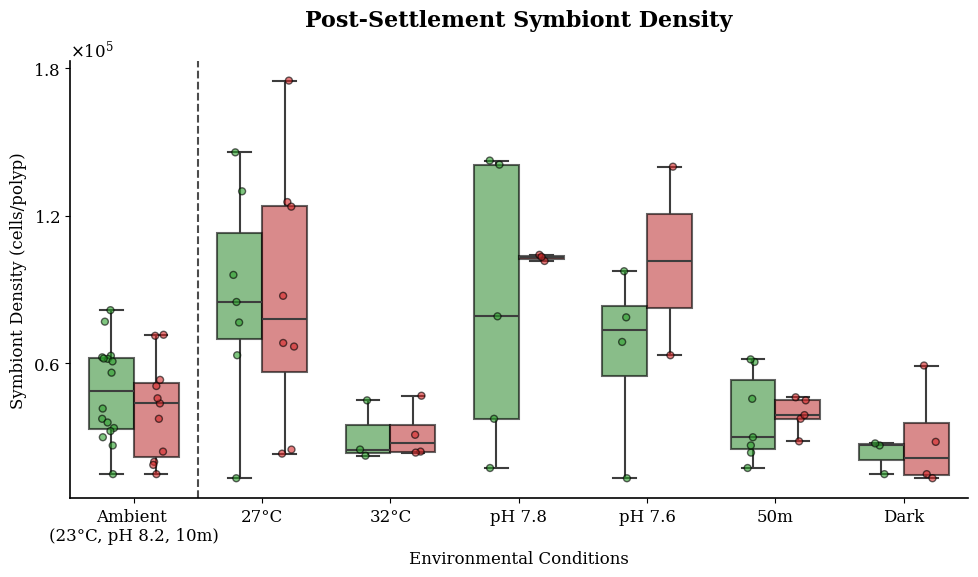

Saved: Poster_Plot_Cell_per_area_um2.svg


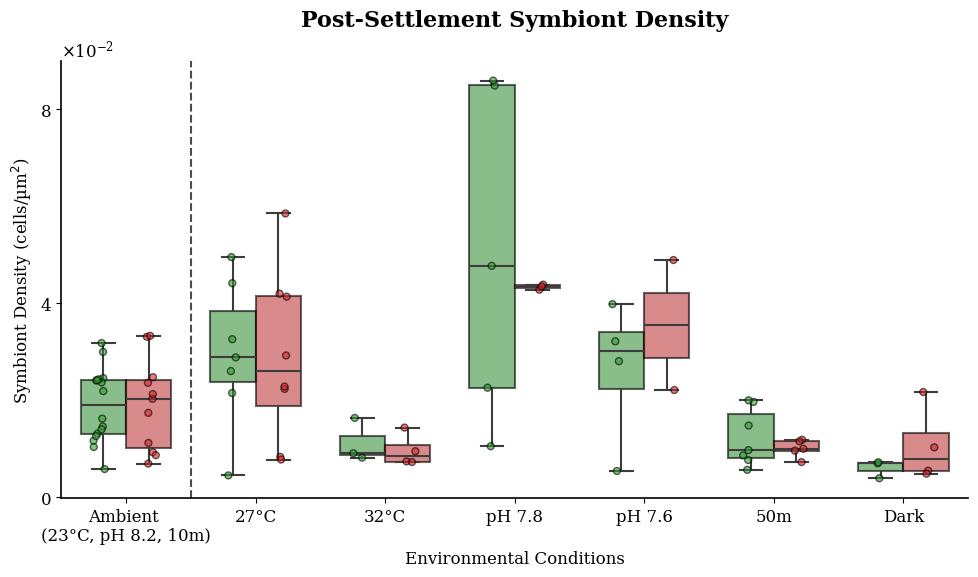

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import PathPatch
import re

metrics_plotting_info = [
    ('Conc (Cell/polyp)', r"Symbiont Density (cells/polyp)"),
    ('Cell_per_area_um2', r"Symbiont Density (cells/µm$^{2}$)")
]

for metric, y_label in metrics_plotting_info:
    plot_df = cleaned_master_dfs[metric].copy()
    p_vals = final_p_values.get(metric, {})

    plt.figure(figsize=global_fig_size)
    ax = plt.gca()

    # Generate boxplot with updated width (0.7) and black edges
    sns.boxplot(data=plot_df, x='Sub_Condition', y=metric, hue='morph',
                hue_order=['HF', 'NF'], palette=variant_colors, width=0.7,
                showfliers=False, linewidth=1.5,
                boxprops={'edgecolor': 'black', 'alpha': 0.6},
                order=sub_condition_plot_order, ax=ax)

    # Exhaustive loop to force 0.6 alpha on all box faces
    for artist in ax.get_children():
        if isinstance(artist, PathPatch):
            r, g, b, _ = artist.get_facecolor()
            artist.set_facecolor((r, g, b, 0.6))
            artist.set_alpha(0.6)

    # Stripplot on top with jitter opacity set to 0.6
    sns.stripplot(data=plot_df, x='Sub_Condition', y=metric, hue='morph',
                  hue_order=['HF', 'NF'], palette=variant_colors, size=global_marker_size,
                  jitter=global_jitter, alpha=0.6, dodge=True, zorder=5,
                  edgecolor='black', linewidth=1, order=sub_condition_plot_order, ax=ax)

    # Add vertical dashed line to separate Ambient from experimental treatments
    ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

    max_y = plot_df[metric].max()
    # Using enumerate correctly to match index for text placement
    for idx, sub_label in enumerate(sub_condition_plot_order):
        p_val = p_vals.get(sub_label, 1.0)
        if p_val < 0.05:
            label = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else "*")
            ax.text(idx, max_y * 1.05, label, ha='center', va='bottom',
                    fontsize=global_asterisk_size, fontweight=global_asterisk_weight)

    ax.set_title("Post-Settlement Symbiont Density", pad=25)
    ax.set_ylabel(y_label)
    ax.set_xlabel("Environmental Conditions")

    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=global_y_nbins))

    if ax.get_legend():
        ax.get_legend().remove()

    sns.despine()
    plt.tight_layout()

    clean_name = re.sub(r'[^a-zA-Z0-9]', '_', metric)
    file_path = f"Poster_Plot_{clean_name}.svg"
    plt.savefig(file_path, format='svg', transparent=False)
    print(f"Saved: {file_path}")

    plt.show()